# Ejercicio: Optimización Bayesiana
### Nombre: Gibrán Leonardo Chávez González
### Fecha: 23/03/26

In [154]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt

In [155]:
gp = GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)

Nos dan los primeros puntos

In [156]:
X = np.array(
    [[10], [2], [3], [7], [12]]
)

y = np.array(
    [[2847], [-4017], [-1255], [1773], [563]]
)

Entrenamos el modelo con los valores que ya tenemos

In [157]:
gp.fit(X, y)

,kernel,None
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,42


Crear simulacion

In [158]:
X_sim = np.linspace(start=2, stop=15, num=10001).reshape(-1, 1)
X_sim

array([[ 2.    ],
       [ 2.0013],
       [ 2.0026],
       ...,
       [14.9974],
       [14.9987],
       [15.    ]], shape=(10001, 1))

Predecimos con el nuevo vector de simulacion (con su desviación estándar)

In [159]:
y_pred, sigma = gp.predict(X_sim, return_std=True)
y_pred

array([-4.01700000e+03, -4.01552264e+03, -4.01403659e+03, ...,
        2.06700829e+00,  2.05894051e+00,  2.05090082e+00], shape=(10001,))

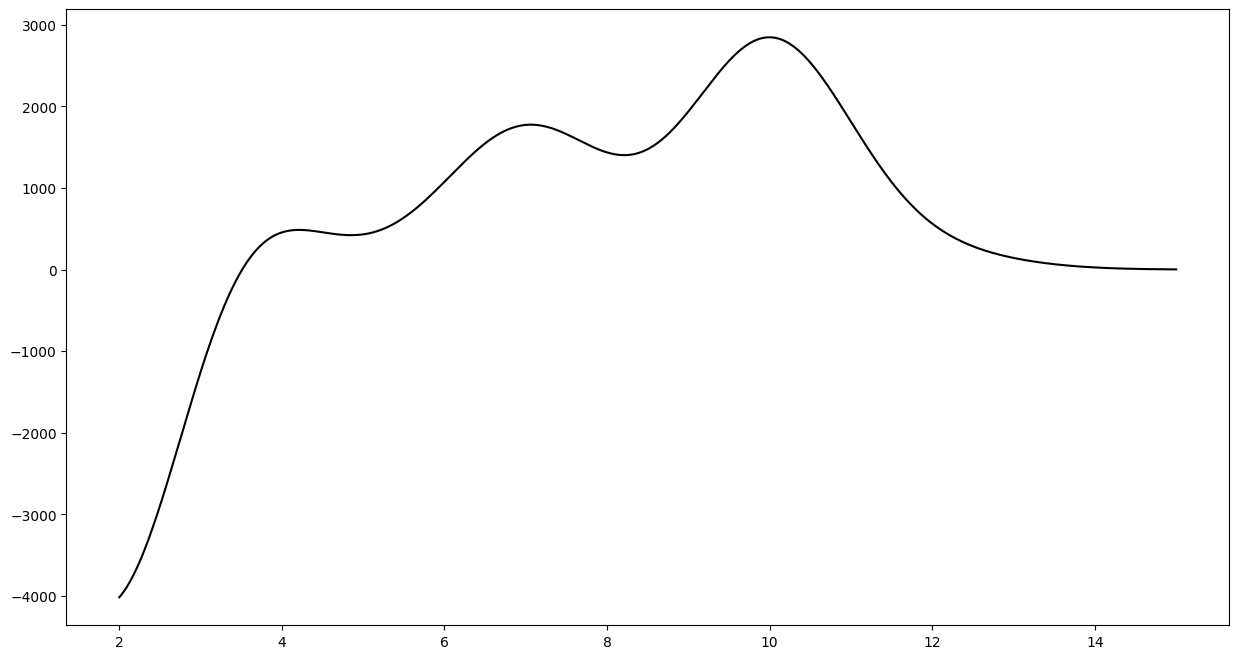

In [160]:
plt.figure(figsize=(15, 8)); plt.plot(X_sim, y_pred, color='black'); plt.show()

Creamos intervalos de confianza y los añadimos a la gráfica

In [161]:
y_upper = y_pred + 2 * sigma
y_lower = y_pred - 2 * sigma

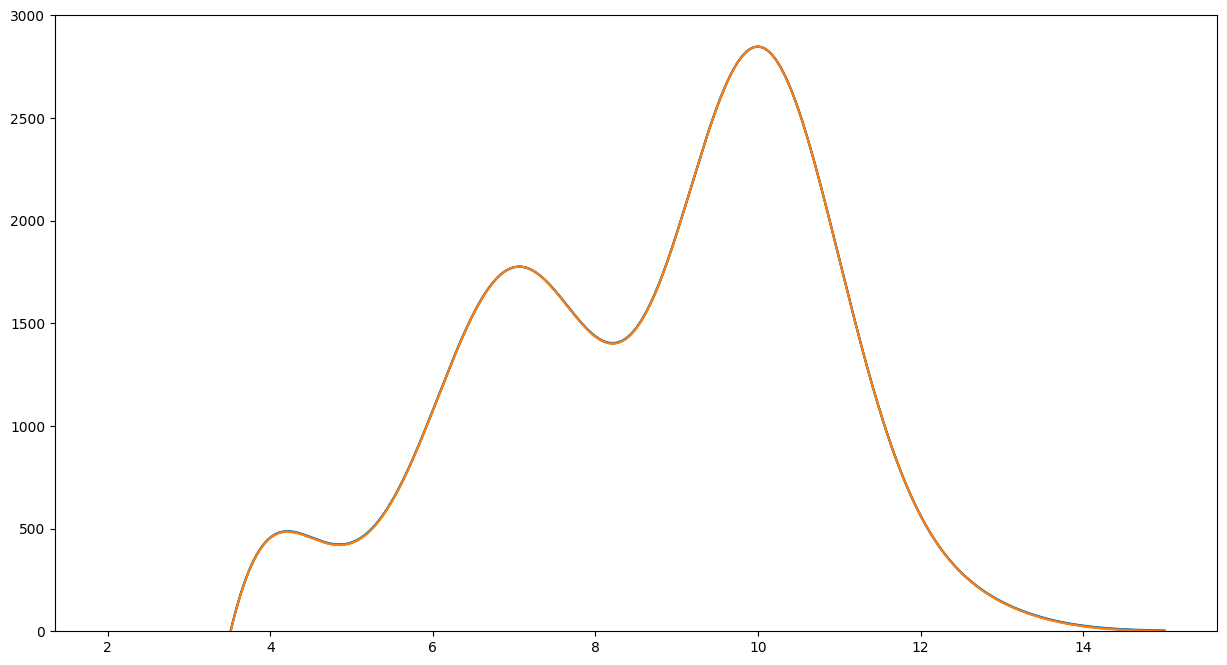

In [162]:
plt.figure(figsize=(15, 8))
plt.ylim([0, 3000])
plt.plot(X_sim, y_pred, color='black')
plt.plot(X_sim, y_upper)
plt.plot(X_sim, y_lower)
#plt.fill_between(X_sim.ravel(), y_upper.ravel(), y_lower.ravel(), alpha=0.5, color='green')
plt.show()

Buscamos la X con el intervalo de confianza más alto

In [163]:
i_max = np.argmax(y_upper)
X_max = X_sim[i_max]
X_max

array([9.9963])

Añadimos al vector X el índice donde la sigma de X_sim es mayor

In [164]:
X = np.vstack([X, X_max])
y = np.vstack([y, 2847.31363])

Volvemos a simular, crear una y predictora para ver si el valor máximo cambió

In [165]:
gp.fit(X, y)
y_pred, sigma = gp.predict(X_sim, return_std=True)

In [166]:
y_upper = y_pred + 2 * sigma
y_lower = y_pred - 2 * sigma

In [167]:
i_max = np.argmax(y_upper)
X_max = X_sim[i_max]
X_max

array([9.9651])

In [168]:
X = np.vstack([X, X_max])
y = np.vstack([y, 2849.5981])

gp.fit(X, y)
y_pred, sigma = gp.predict(X_sim, return_std=True)

y_upper = y_pred + 2 * sigma
y_lower = y_pred - 2 * sigma

i_max = np.argmax(y_upper)
X_max = X_sim[i_max]
X_max

array([9.8741])

In [169]:
X = np.vstack([X, X_max])
y = np.vstack([y, 2852.69711])

gp.fit(X, y)
y_pred, sigma = gp.predict(X_sim, return_std=True)

y_upper = y_pred + 2 * sigma
y_lower = y_pred - 2 * sigma

i_max = np.argmax(y_upper)
X_max = X_sim[i_max]
X_max

array([9.8637])

Conclusiones:

Este proceso nos sirve para poder optimizar un hiperparámetro. Personalmente, me parece interesante que no existe un valor meta al que debas llegar como tal, sino que es un valor con el que tú te sientas satisfecho, o veas que no hay mucho cambio entre cada uno.